In [4]:
import numpy as np
import matplotlib.pyplot as plt

from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
)
from kuramoto.analysis import order_parameter
from kuramoto.adjoint import grads_final_R, grads_mean_R
from kuramoto.plotting import plot_2d
from kuramoto.network import (
    create_cortical_graph,
    plot_cortical_graph,
    get_degree,
    get_deg_centrality,
    get_closeness_centrality,
    get_betweenness_centrality,
    get_eigenvector_centrality,
)

SEED = 42
grid_shape = (16, 16)


# Simple graph
cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        mode="spatial",
        kernel="gaussian",
        base_strength=1.0,
        radius=5.0,
        kernel_params={"sigma": 2.0},
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=SEED,
)

sim_simple = build_simulation(config=cfg, rng=np.random.default_rng(SEED))

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

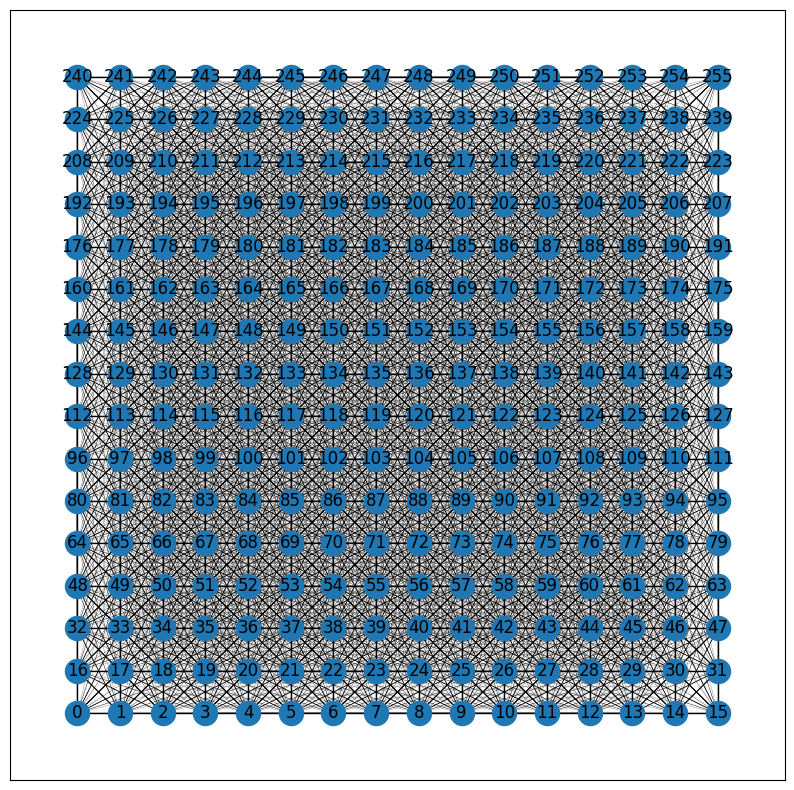

In [5]:
G = create_cortical_graph(sim_simple)

plot_cortical_graph(G, layout="grid")

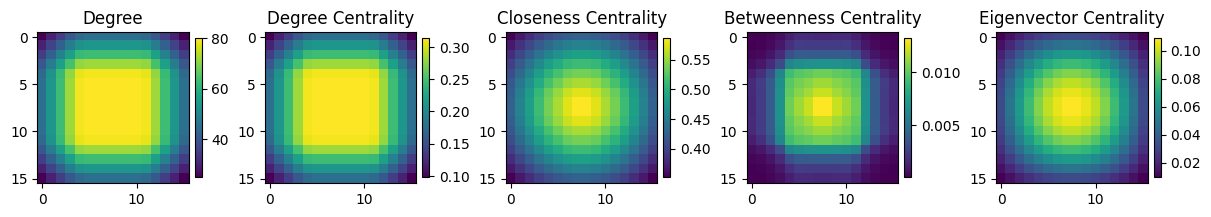

In [6]:
deg = get_degree(G)
deg_cent = get_deg_centrality(G)
closeness = get_closeness_centrality(G)
betweenness = get_betweenness_centrality(G)
eigenvector = get_eigenvector_centrality(G)

fig,ax = plt.subplots(1,5,figsize=(12,16),constrained_layout=True)
im = ax[0].imshow(deg.reshape(grid_shape))
ax[0].set_title("Degree")
fig.colorbar(im,ax=ax[0],fraction=0.046, pad=0.04)
im = ax[1].imshow(deg_cent.reshape(grid_shape))
ax[1].set_title("Degree Centrality")
fig.colorbar(im,ax=ax[1],fraction=0.046, pad=0.04)
im = ax[2].imshow(closeness.reshape(grid_shape))
ax[2].set_title("Closeness Centrality")
fig.colorbar(im,ax=ax[2],fraction=0.046, pad=0.04)
im = ax[3].imshow(betweenness.reshape(grid_shape))
ax[3].set_title("Betweenness Centrality")
fig.colorbar(im,ax=ax[3],fraction=0.046, pad=0.04)
im = ax[4].imshow(eigenvector.reshape(grid_shape))
ax[4].set_title("Eigenvector Centrality")
fig.colorbar(im,ax=ax[4],fraction=0.046, pad=0.04)

### 2) Heterogeneous sim

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

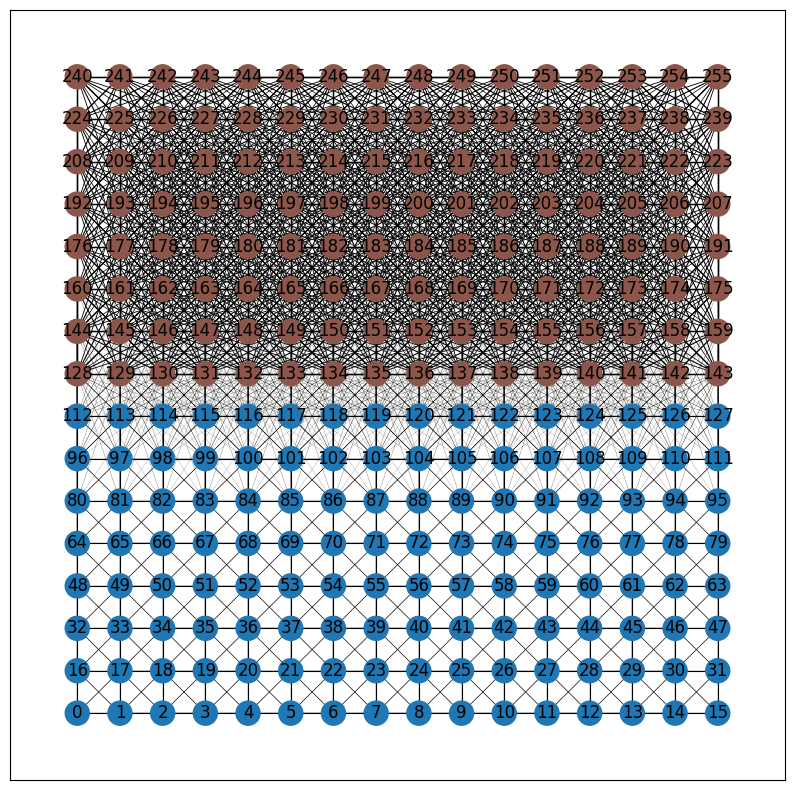

In [7]:
# Heterogeneous graph
n_rows, n_cols = grid_shape
group_ids = np.zeros((n_rows, n_cols), dtype=int)
group_ids[n_rows // 2 :, :] = 1 # Top half is group 1, bottom half is group 0
group_ids = group_ids.ravel().tolist()

components = [
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=1.0,
        kernel_params={"sigma": 1.0},
        radius=2.0,
        node_groups=[0],
        edge_mode="within",
    ),
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=0.8,
        kernel_params={"sigma": 3.0},
        radius=4.0,
        node_groups=[1],
        edge_mode="within",
    ),
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=0.4,
        kernel_params={"sigma": 2.0},
        radius=4.0,
        node_groups=[1],
        edge_mode="custom",
        to_node_groups=[0],
    ),
    # KernelComponentConfig(
    #     kernel="gaussian",
    #     base_strength=0.4,
    #     kernel_params={"sigma": 2.0},
    #     radius=4.0,
    #     node_groups=[0],
    #     edge_mode="custom",
    #     to_node_groups=[1],
    # ),
]

cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        kernel="gaussian",
        base_strength=1.0,
        radius=4.0,
        mode="spatial",
        components=components,
        group_ids=group_ids,
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)

sim_hetero = build_simulation(config=cfg, rng=np.random.default_rng(SEED))

G = create_cortical_graph(sim_hetero)

plot_cortical_graph(G, layout="grid")

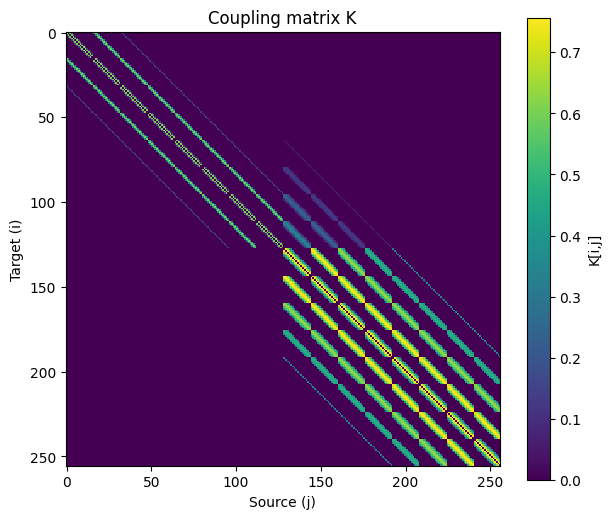

In [8]:
from kuramoto.plotting import plot_coupling_matrix
plot_coupling_matrix(sim_hetero.coupling.K)

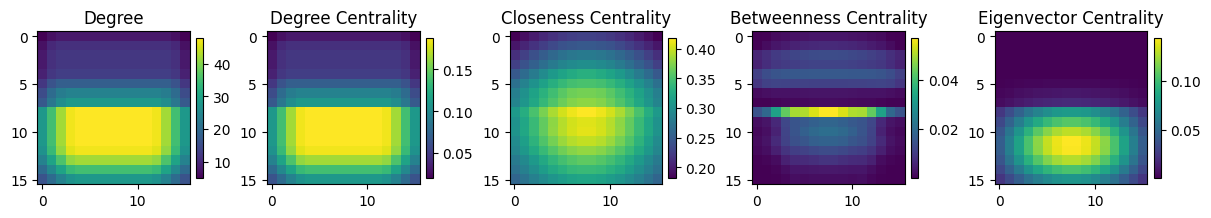

In [9]:
deg = get_degree(G)
deg_cent = get_deg_centrality(G)
closeness = get_closeness_centrality(G)
betweenness = get_betweenness_centrality(G)
eigenvector = get_eigenvector_centrality(G)

fig,ax = plt.subplots(1,5,figsize=(12,16),constrained_layout=True)
im = ax[0].imshow(deg.reshape(grid_shape))
ax[0].set_title("Degree")
fig.colorbar(im,ax=ax[0],fraction=0.046, pad=0.04)
im = ax[1].imshow(deg_cent.reshape(grid_shape))
ax[1].set_title("Degree Centrality")
fig.colorbar(im,ax=ax[1],fraction=0.046, pad=0.04)
im = ax[2].imshow(closeness.reshape(grid_shape))
ax[2].set_title("Closeness Centrality")
fig.colorbar(im,ax=ax[2],fraction=0.046, pad=0.04)
im = ax[3].imshow(betweenness.reshape(grid_shape))
ax[3].set_title("Betweenness Centrality")
fig.colorbar(im,ax=ax[3],fraction=0.046, pad=0.04)
im = ax[4].imshow(eigenvector.reshape(grid_shape))
ax[4].set_title("Eigenvector Centrality")
fig.colorbar(im,ax=ax[4],fraction=0.046, pad=0.04)

In [10]:
T_END = 5.0
dt = 0.1
RNG = np.random.default_rng(42)

results = sim_hetero.run((0, T_END), dt, rng=RNG)
t_list = results['ts'].tolist()
state_list = [{'theta': th, 'theta_dot': dth, 'omega': results['omega']} for th, dth in zip(results['theta'], results['theta_dot'])]

# Postprocess
R_list, _ = order_parameter(results['theta'])

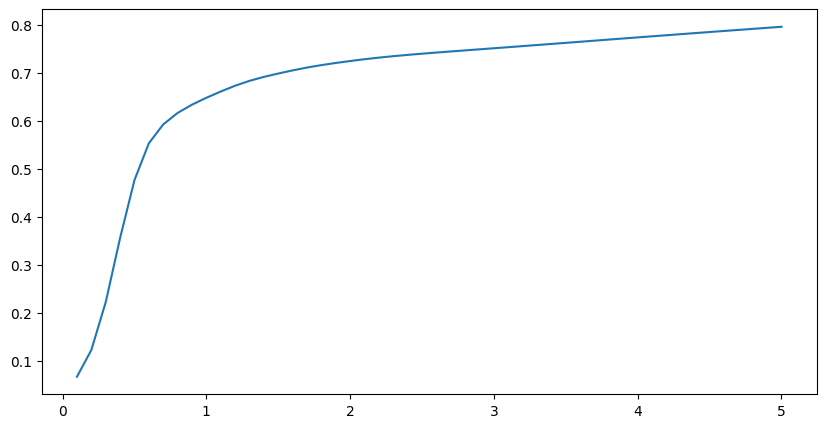

In [13]:
fig,ax = plt.subplots(figsize=(10,5))
ax.plot(results["ts"], R_list, linewidth=1.5)